## On the use of hierarchical Bayesian modelling for stochastic crack growth monitoring

### Case 2 - Modelling crack growth in ship structures using a spectral fatigue analysis and a stochastic modified Paris' law model

This notebook demonstrates the principles of the proposed hierarchical Bayesian modelling framework using data obtained from a physics-based stochastic simulation that generates crack growth data for structural components in ship structures, operating under realistic conditions. The framework employed to generate these results is presented in Makris et al. (2023).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

notebook_path = Path().absolute()
project_root = notebook_path.parent
sys.path.append(str(project_root))
from src.data_utils import SCGDataLoader

In [3]:
data_loader = SCGDataLoader()

In [4]:
data = data_loader.load_data()

In [5]:
%matplotlib inline

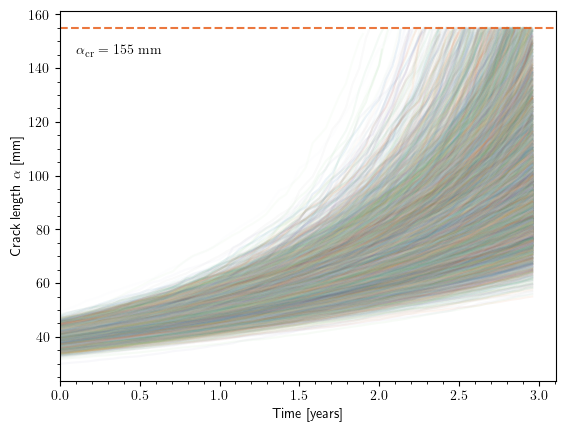

In [6]:
from src.visualisation import plot_scg_data

plot_scg_data(data["times"], data["crack_lengths"], save_fig_name="scg_data.pdf")

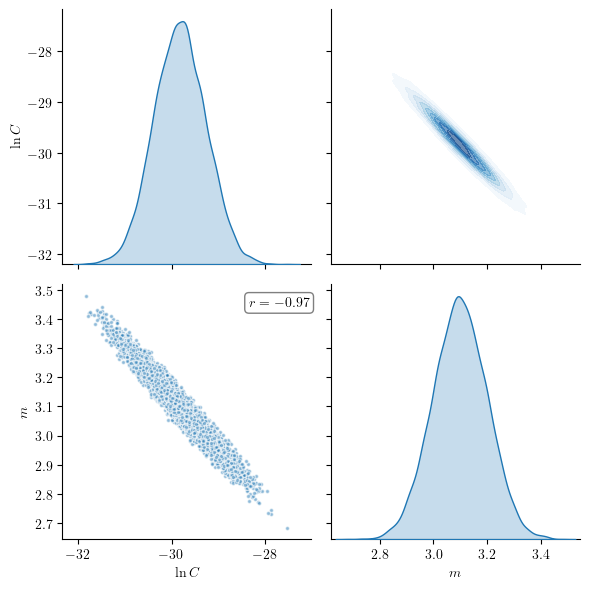

In [7]:
from src.visualisation import paris_params_pair_plot
paris_params_pair_plot(data["paris_c"], data["paris_m"], save_fig_name="paris_params_pair_plot.pdf")

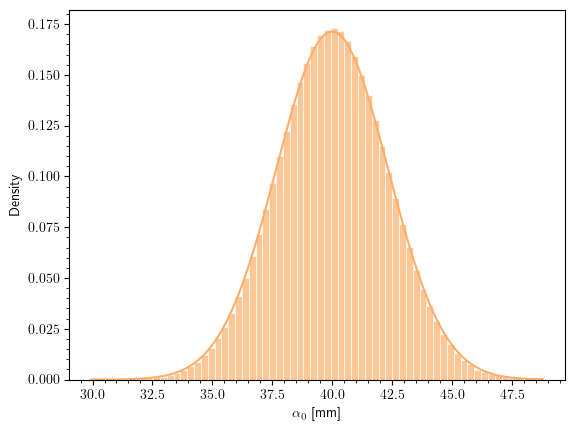

In [8]:
from src.visualisation import plot_initial_crack_length
plot_initial_crack_length(data["initial_crack_length"], save_fig_name="a0_hist.pdf")

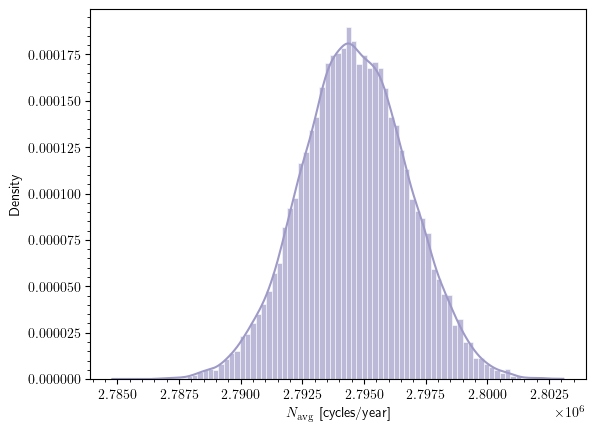

In [9]:
from src.visualisation import plot_avg_cycles
plot_avg_cycles(data["avg_cycles"], save_fig_name="avg_cycles_hist.pdf")

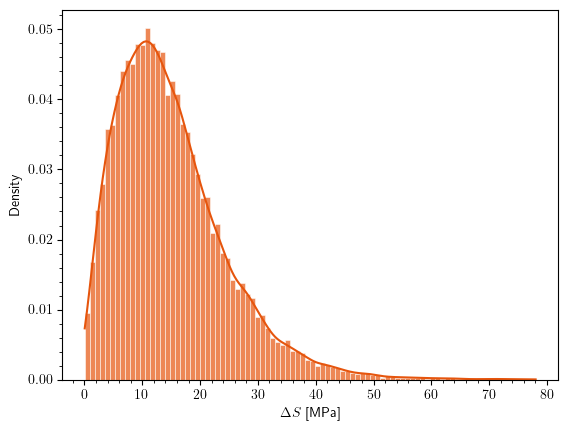

In [10]:
from src.visualisation import plot_stress_ranges
plot_stress_ranges(data["stress_ranges"], save_fig_name="stress_ranges_hist.pdf")

## Visualizing Selected Crack Growth Trajectories

Here we demonstrate the new functions for visualizing selected trajectories and observations.

In [11]:
# Import our new trajectory selector and observation generator
from src.data_utils import TrajectorySelector, CrackObservationGenerator
from src.visualisation import plot_selected_trajectories, plot_trajectories_with_observations

In [12]:
# First, let's select some trajectories with similar Paris law parameters
trajectory_selector = TrajectorySelector(data)

# Set target parameters for selection (similar to what we did in the HBM_for_SCG notebook)
# This will internally calculate target parameters based on the data statistics
trajectory_selector._set_target_parameters(scale_logc=-1.5, scale_m=1.5)

# Select trajectories that are within 1% of the standard deviation from the targets
selected_indices = trajectory_selector.select_by_radius(radius=0.01)
print(f"Found {len(selected_indices)} trajectories matching the criteria")

# Extract the selected trajectories
selected_trajectories = trajectory_selector.extract_trajectories(selected_indices)

# Print Paris parameters of selected trajectories
print("Paris parameters of selected trajectories:")
for i, (c, m) in enumerate(zip(selected_trajectories['paris_c'], selected_trajectories['paris_m'])):
    print(f"Trajectory {i+1}: C={c:.2e}, m={m:.4f}")

Found 3 trajectories matching the criteria
Paris parameters of selected trajectories:
Trajectory 1: C=4.80e-14, m=3.2491
Trajectory 2: C=4.82e-14, m=3.2482
Trajectory 3: C=4.79e-14, m=3.2494


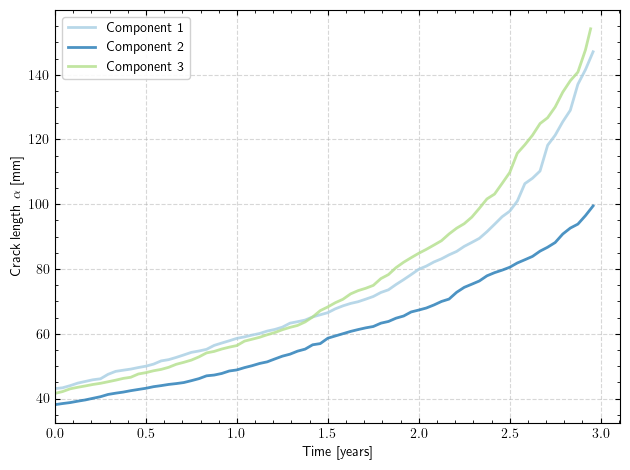

In [13]:
# Visualize the selected trajectories
fig, ax = plot_selected_trajectories(
    times=selected_trajectories['times'],
    crack_lengths=selected_trajectories['crack_lengths'],
    labels=[f"Component {i+1}" for i in range(len(selected_indices))],
    cmap_name='Paired',
    figsize=(6.4, 4.8),
    alpha=0.8,
    save_fig_name="selected_trajectories_pm.pdf"
)

## Simulating and Visualizing Crack Observations

Now let's generate simulated observations from these trajectories and visualize them.

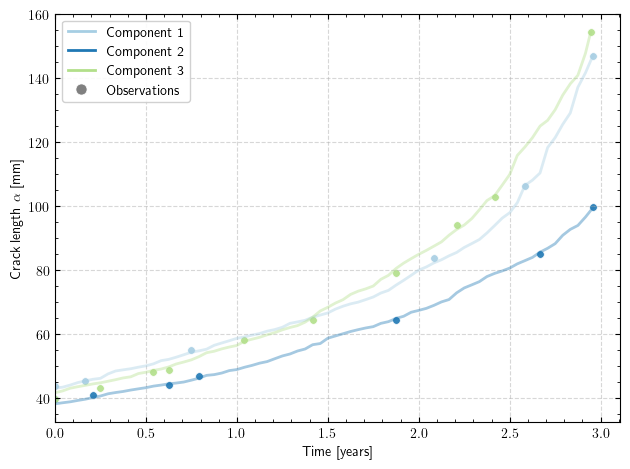

In [14]:
# Create an observation generator based on the selected trajectories
obs_generator = CrackObservationGenerator(selected_trajectories, random_seed=42)

# Generate observations using random sampling with noise
observations = obs_generator.create_observations(
    n_points=[6, 7, 10],           # 10 observations per trajectory
    strategy='random',     # Random sampling across the timeline
    std_dev=1.0,           # 1mm standard deviation measurement noise
    include_endpoints=True,  # Always include start and end points
    random_seed=42
)

# Visualize the trajectories with observations
fig, ax = plot_trajectories_with_observations(
    times=selected_trajectories['times'],
    crack_lengths=selected_trajectories['crack_lengths'],
    obs_times=observations['times'],
    obs_lengths=observations['noisy_crack_lengths'],
    labels=[f"Component {i+1}" for i in range(len(selected_indices))],
    cmap_name='Paired',
    figsize=(6.4, 4.8),
    traj_alpha=0.4,        # Make the trajectories slightly transparent
    obs_alpha=0.9,         # Make the observations more visible
    marker_size=30,        # Increase marker size for visibility
    save_fig_name="trajectories_with_observations.pdf"
)

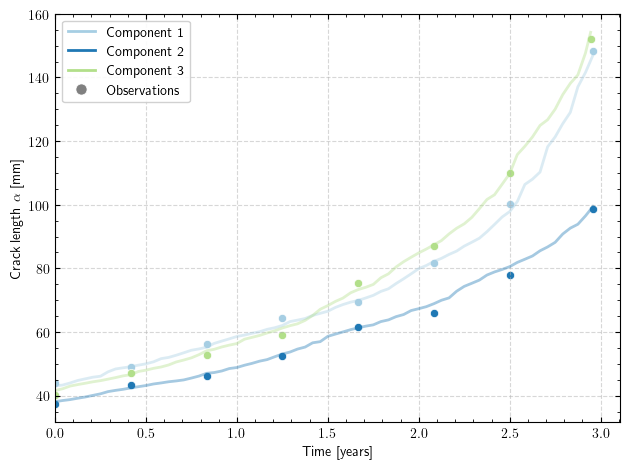

In [15]:
# Let's also try uniform sampling, which is more systematic
uniform_observations = obs_generator.create_observations(
    n_points=8,            # 8 observations per trajectory
    strategy='uniform',    # Evenly spaced observations
    std_dev=1.5,           # Slightly higher noise for demonstration
    include_endpoints=True,
    random_seed=42
)

# Visualize with uniform sampling
fig, ax = plot_trajectories_with_observations(
    times=selected_trajectories['times'],
    crack_lengths=selected_trajectories['crack_lengths'],
    obs_times=uniform_observations['times'],
    obs_lengths=uniform_observations['noisy_crack_lengths'],
    labels=[f"Component {i+1}" for i in range(len(selected_indices))],
    cmap_name='Paired',
    figsize=(6.4, 4.8),
    traj_alpha=0.4,
    obs_alpha=1.0,
    marker_size=35,
    save_fig_name="uniform_observations.pdf"
)

# Add title to indicate this is uniform sampling
# ax.set_title("Crack Growth Trajectories with Uniformly Sampled Observations")

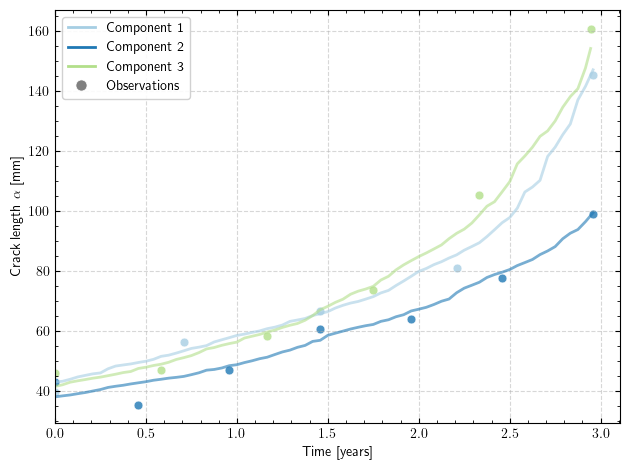

In [16]:
# Finally, let's demonstrate different noise levels
# Higher noise to illustrate measurement uncertainty
high_noise_observations = obs_generator.create_observations(
    n_points=[5, 7, 6],    # Different number of points for each trajectory
    strategy='uniform',
    std_dev=3.0,           # Higher noise level
    include_endpoints=True,
    random_seed=123
)

fig, ax = plot_trajectories_with_observations(
    times=selected_trajectories['times'],
    crack_lengths=selected_trajectories['crack_lengths'],
    obs_times=high_noise_observations['times'],
    obs_lengths=high_noise_observations['noisy_crack_lengths'],
    labels=[f"Component {i+1}" for i in range(len(selected_indices))],
    cmap_name='Paired',
    figsize=(6.4, 4.8),
    traj_alpha=0.6,
    obs_alpha=0.8,
    marker_size=40,
    save_fig_name="high_noise_observations.pdf"
)

# Add title to indicate the high noise level
# ax.set_title(r"Crack Growth Trajectories with High Measurement Uncertainty ($\sigma = 3.0$ mm)")

# Add text to explain what's being shown
# ax.text(0.02, 0.02, 
#         "Solid lines: True crack growth trajectories\nPoints: Simulated measurements with noise", 
#         transform=ax.transAxes, 
#         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'),
#         fontsize=9)

## Bayesian Inference for Crack Growth Parameters

In this section, we'll use the Bayesian model we've implemented to infer Paris law parameters from observed crack growth data. We'll start with a single component and then expand to multiple components.

In [21]:
import numpy as np

In [22]:
import numpyro.distributions as dist
from src.bayesian_models import STLBayesianModel
from src.visualisation import plot_posterior_trace

# Set a seed for reproducibility
np.random.seed(42)

In [23]:
# First, let's define our priors for the model
# These priors are based on domain knowledge about Paris law parameters
priors = {
    "logc": dist.Normal(-30.0, 2.0),      # Natural log of C parameter
    "m": dist.Normal(3.2, 0.5),           # Paris law exponent
    "ds": dist.Weibull(14.9, 1.6),           # Stress range (MPa)
    "noise_std": dist.HalfNormal(2.0)     # Observation noise (mm)
}

# Component index to start with
component_idx = 0

# Extract the true parameters for this component from the selected trajectories
true_logc = np.log(selected_trajectories['paris_c'][component_idx])
true_m = selected_trajectories['paris_m'][component_idx]
true_a0 = selected_trajectories['initial_crack_length'][component_idx]

print(f"True parameters for component {component_idx + 1}:")
print(f"logC: {true_logc:.4f}")
print(f"m: {true_m:.4f}")
print(f"a0: {true_a0:.4f}")

True parameters for component 1:
logC: -30.6669
m: 3.2491
a0: 43.0770


In [24]:
# Create the Bayesian model
# We'll use the uniform observations we created earlier
model = STLBayesianModel(priors=priors, crack_growth_data=uniform_observations)

# Run inference with MCMC
# For demonstration, we're using fewer samples than we would in practice
results = model.run_inference(
    component_idx=component_idx,
    navg = 2.8e6,       # Average cycles per year
    num_warmup=2000,    # Number of warmup steps
    num_samples=2000,   # Number of samples to draw
    num_chains=4,       # Number of chains to run
    progress_bar=True   # Show progress bar during sampling
)

/Users/nikos/Library/CloudStorage/OneDrive-Personal/Research (NTUA)/Postdoctoral Research/Stochastic Crack Growth Monitoring/Code/src/bayesian_models.py:151: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  self.mcmc = MCMC(
sample: 100%|██████████| 4000/4000 [00:01<00:00, 2372.00it/s, 11 steps of size 3.71e-03. acc. prob=0.88]  


In [25]:
# Print full posterior summary
model.summarise_posterior(print_summary=True)
# Print summary statistics
print("\nPosterior summary:")
print(f"Inferred logC: {results['summary']['mean']['logc']:.4f} ± {results['summary']['sd']['logc']:.4f}")
print(f"Inferred m: {results['summary']['mean']['m']:.4f} ± {results['summary']['sd']['m']:.4f}")
print(f"Inferred noise_std: {results['summary']['mean']['noise_std']:.4f} ± {results['summary']['sd']['noise_std']:.4f}")

                               mean     sd   hdi_3%  hdi_97%  mcse_mean  \
ds                            7.970  4.715    1.770   16.542      0.113   
logc                        -30.909  1.825  -34.264  -27.380      0.042   
m                             4.156  0.416    3.364    4.909      0.013   
noise_std                     4.254  0.956    2.545    5.979      0.028   
predicted_crack_lengths[0]   48.781  0.364   48.127   49.469      0.011   
predicted_crack_lengths[1]   54.966  0.777   53.593   56.461      0.023   
predicted_crack_lengths[2]   62.875  1.226   60.651   65.190      0.036   
predicted_crack_lengths[3]   73.313  1.667   70.302   76.495      0.048   
predicted_crack_lengths[4]   87.661  2.003   84.083   91.535      0.053   
predicted_crack_lengths[5]  108.489  2.219  104.289  112.672      0.038   
predicted_crack_lengths[6]  141.148  4.271  133.074  149.282      0.078   

                            mcse_sd  ess_bulk  ess_tail  r_hat  
ds                            0.11

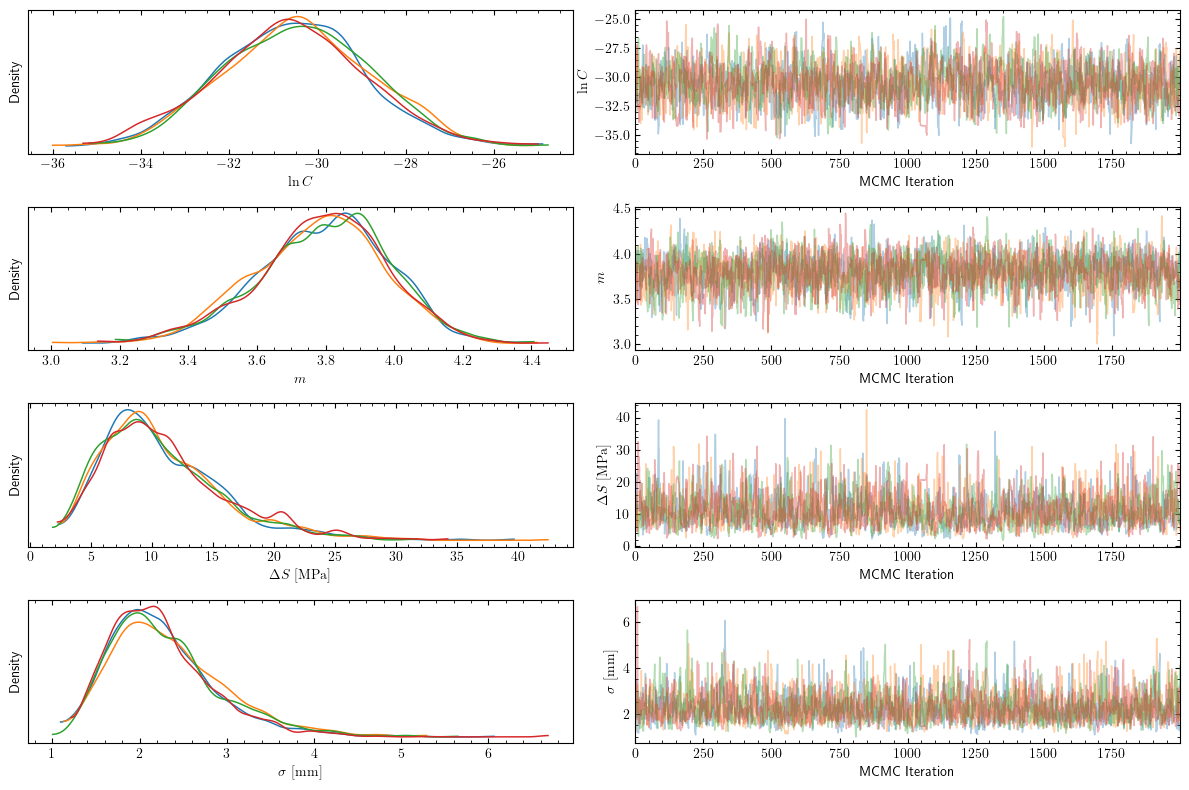

In [93]:
# Visualize posterior distributions
var_names = ["logc", "m", "ds", "noise_std"]
plot_var_names= [r"$\ln C$",  r"$m$", r"$\Delta S \ \mathrm{[MPa]}$", r"$\sigma \ \mathrm{[mm]}$"]
plot_posterior_trace(results['samples'], var_names=var_names, plot_var_names=plot_var_names,
                      save_fig_name="posterior_traces_stl_c3.pdf")

## Comparing Prior and Posterior Distributions

We can use the new `plot_prior_posterior_comparison` function to visualize both prior and posterior distributions alongside the true parameter values and the posterior mode.

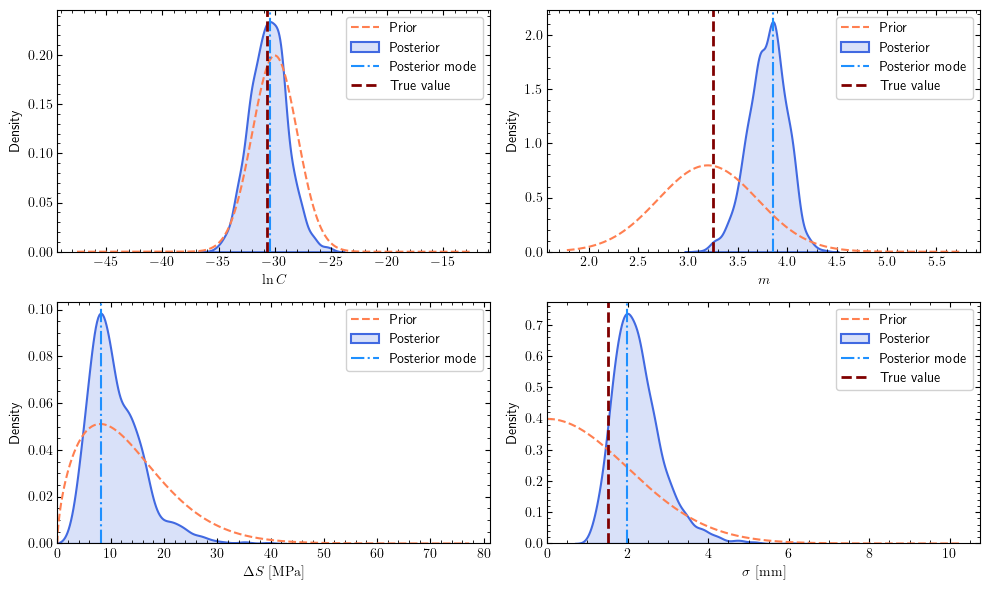

In [94]:
# Import necessary modules
import numpy as np
import numpyro.distributions as dist
from src.visualisation import plot_prior_posterior_comparison

# # Define the priors (same as used in the model)
# priors = {
#     "logc": dist.Normal(-30.0, 2.0),      # Natural log of C parameter
#     "m": dist.Normal(3.2, 0.5),           # Paris law exponent
#     "ds": dist.Gamma(5.0, 0.3),           # Stress range (MPa)
#     "noise_std": dist.HalfNormal(2.0)     # Observation noise (mm)
# }

# Define the true values (for demonstration)
true_values = {
    "logc": true_logc,
    "m": true_m,
    "noise_std": 1.5  # Noise used in generating observations
}

# Extract posterior samples
posterior_samples = results['samples']

# Define nice display names for plotting
plot_labels = {
    "logc": r"$\ln C$",
    "m": r"$m$",
    "ds": r"$\Delta S \ \mathrm{[MPa]}$",
    "noise_std": r"$\sigma \ \mathrm{[mm]}$"
}

# Create the comparison plot with extended prior range for better visualization
fig, axes = plot_prior_posterior_comparison(
    posterior_samples=posterior_samples,
    prior_dists=priors,
    true_values=true_values,
    var_names=var_names,
    plot_var_names=plot_labels,
    figsize=(10.0, 6.0),
    n_cols=2,
    point_estimate='mode',
    save_fig_name="prior_posterior_comparison_stl_c3.pdf",
    use_first_chain_only=True,
    prior_range_extension=2.5
)

In [95]:
# Generate predictions from the posterior
posterior_predictions = model.generate_predictions(
    num_samples=1000,  # Use 100 samples for more efficient visualization
    component_idx=component_idx,
    navg=2.8e6,
    random_seed=42
)

In [96]:
# Use the new visualization function to plot posterior predictive samples
from src.visualisation import plot_posterior_predictive_stl

# Get times and data for plotting
true_times = selected_trajectories['times'][component_idx]
true_crack_lengths = selected_trajectories['crack_lengths'][component_idx]
observed_times = uniform_observations['times'][component_idx]
observed_crack_lengths = uniform_observations['noisy_crack_lengths'][component_idx]



Comparison of statistics:
Predictions RMSE: 1.909 mm
Observations RMSE: 1.947 mm

95% CI width at final time:
Predictions: 8.62 mm
Observations: 12.51 mm


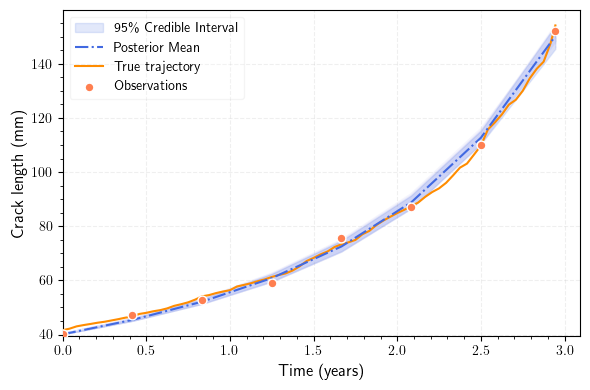

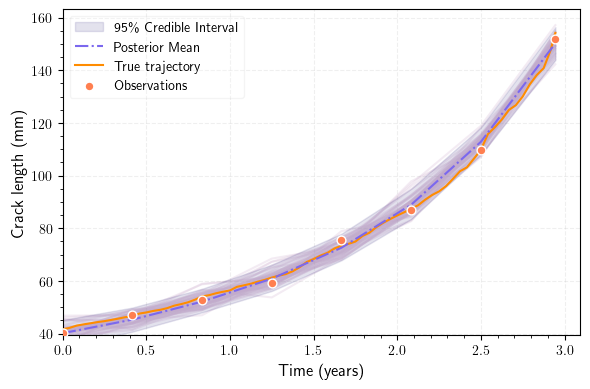

In [97]:
# Generate predictions using the proper posterior predictive sampling method
posterior_predictive_output = model.generate_posterior_predictive(
    num_samples=1000,
    component_idx=component_idx,
    navg=2.8e6,
    random_seed=42
)

# Plot the predicted crack lengths (default behavior)
fig1, ax1, stats1 = plot_posterior_predictive_stl(
    posterior_predictions=posterior_predictive_output,
    true_times=true_times,
    true_crack_lengths=true_crack_lengths,
    observed_times=observed_times,
    observed_crack_lengths=observed_crack_lengths,
    max_samples=50,
    figsize=(6, 4),
    save_fig_name="posterior_predictive_predictions_stl_c3.pdf"
)

# Plot only the observations with noise
fig2, ax2, stats2 = plot_posterior_predictive_stl(
    posterior_predictions=posterior_predictive_output,
    true_times=true_times,
    true_crack_lengths=true_crack_lengths,
    observed_times=observed_times,
    observed_crack_lengths=observed_crack_lengths,
    max_samples=50,
    figsize=(6, 4),
    plot_type="observations",  # Plot observations instead of predictions
    save_fig_name="posterior_predictive_observations_stl_c3.pdf"
)

# Print comparison of statistics
print("\nComparison of statistics:")
print(f"Predictions RMSE: {stats1['rmse']:.3f} mm")
print(f"Observations RMSE: {stats2['rmse']:.3f} mm")

print("\n95% CI width at final time:")
print(f"Predictions: {stats1['ci_width'][-1]:.2f} mm")
print(f"Observations: {stats2['ci_width'][-1]:.2f} mm")


## Using the Output Utilities Module for Parameter Comparison

We'll use the new `output_utils` module to calculate error metrics and create formatted comparison tables for our Bayesian inference results across different components.

In [39]:
from src.output_utils import calculate_component_metrics, format_comparison_table, save_results_table

# Now let's run the model on all three components to compare performance
component_results = []

for i in range(len(selected_indices)):
    print(f"\nRunning inference for component {i+1}...")
    
    # Extract true parameters
    true_logc = np.log(selected_trajectories['paris_c'][i])
    true_m = selected_trajectories['paris_m'][i]
    true_a0 = selected_trajectories['initial_crack_length'][i]
    
    print(f"True parameters for component {i + 1}:")
    print(f"logC: {true_logc:.4f}")
    print(f"m: {true_m:.4f}")
    print(f"a0: {true_a0:.4f}")
    
    # Create a new model for each component
    # For efficiency, use fewer samples for this comparison
    model = STLBayesianModel(priors=priors, crack_growth_data=uniform_observations)
    results = model.run_inference(
        component_idx=i,
        num_warmup=500,
        num_samples=1000,
        num_chains=2,
        progress_bar=True
    )
    
    # Store results
    component_results.append({
        'index': i,
        'true_params': {
            'logc': true_logc,
            'm': true_m,
            'a0': true_a0,
            'noise_std': 1.5  # The true noise std used for generating observations
        },
        'inferred_params': {
            'logc': results['summary']['mean']['logc'],
            'logc_sd': results['summary']['sd']['logc'],
            'm': results['summary']['mean']['m'],
            'm_sd': results['summary']['sd']['m'],
            'ds': results['summary']['mean']['ds'],
            'ds_sd': results['summary']['sd']['ds'],
            'noise_std': results['summary']['mean']['noise_std'],
            'noise_std_sd': results['summary']['sd']['noise_std']
        }
    })

# Use our new output_utils module to create the comparison table
comparison_df = calculate_component_metrics(component_results)

# Format the table with 4 decimal places
formatted_df = format_comparison_table(comparison_df, precision=4)

# Display the results
print("\nComparison of true vs inferred parameters with multiple metrics:")
formatted_df

/Users/nikos/Library/CloudStorage/OneDrive-Personal/Research (NTUA)/Postdoctoral Research/Stochastic Crack Growth Monitoring/Code/src/bayesian_models.py:151: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  self.mcmc = MCMC(



Running inference for component 1...
True parameters for component 1:
logC: -30.6669
m: 3.2491
a0: 43.0770


sample: 100%|██████████| 1500/1500 [00:00<00:00, 2525.47it/s, 511 steps of size 4.22e-03. acc. prob=0.92]
/Users/nikos/Library/CloudStorage/OneDrive-Personal/Research (NTUA)/Postdoctoral Research/Stochastic Crack Growth Monitoring/Code/src/bayesian_models.py:151: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  self.mcmc = MCMC(



Running inference for component 2...
True parameters for component 2:
logC: -30.6630
m: 3.2482
a0: 38.1200


sample: 100%|██████████| 1500/1500 [00:00<00:00, 2541.86it/s, 1023 steps of size 4.38e-03. acc. prob=0.94]
/Users/nikos/Library/CloudStorage/OneDrive-Personal/Research (NTUA)/Postdoctoral Research/Stochastic Crack Growth Monitoring/Code/src/bayesian_models.py:151: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  self.mcmc = MCMC(



Running inference for component 3...
True parameters for component 3:
logC: -30.6687
m: 3.2494
a0: 41.5960


sample: 100%|██████████| 1500/1500 [00:00<00:00, 1895.98it/s, 1023 steps of size 1.73e-03. acc. prob=0.98]



Comparison of true vs inferred parameters with multiple metrics:


,Component,True logc,Inferred logc,logc SD,True m,Inferred m,m SD,True noise_std,Inferred noise_std,noise_std SD,logc MAPE (%),logc RMSE,m MAPE (%),m RMSE,noise_std MAPE (%),noise_std RMSE
0,1,-30.6669,-31.633,1.650,3.2491,3.977,0.374,1.5,4.491,0.959,3.1502,0.9661,22.4031,0.7279,199.4000,2.9910
1,2,-30.6630,-30.505,1.554,3.2482,3.502,0.286,1.5,2.191,0.597,0.5153,0.1580,7.8136,0.2538,46.0667,0.6910
2,3,-30.6687,-31.062,1.539,3.2494,3.760,0.191,1.5,2.352,0.689,1.2825,0.3933,15.7137,0.5106,56.8000,0.8520
3,Average,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.6493,0.5058,15.3101,0.4974,100.7556,1.5113


In [43]:
# Save the results to a CSV file
save_path = save_results_table(formatted_df, "component_comparison_results")
print(f"\nResults saved to: {save_path}")


Results saved to: /Users/nikos/Library/CloudStorage/OneDrive-Personal/Research (NTUA)/Postdoctoral Research/Stochastic Crack Growth Monitoring/Code/outputs/component_comparison_results.csv


In [75]:
# We can also use the posterior prediction metrics to evaluate model performance
from src.output_utils import calculate_prediction_metrics

for i, component_idx in enumerate(range(len(selected_indices))):
    # Generate posterior predictive samples for this component
    posterior_predictive_output = model.generate_posterior_predictive(
        num_samples=100,
        component_idx=component_idx,
        navg=2.8e6,
        random_seed=42
    )
    
    # Extract true and observed data for this component
    true_times = selected_trajectories['times'][component_idx]
    true_crack_lengths = selected_trajectories['crack_lengths'][component_idx]
    observed_times = uniform_observations['times'][component_idx]
    observed_crack_lengths = uniform_observations['noisy_crack_lengths'][component_idx]
    
    # Calculate mean prediction from posterior samples
    pred_samples = posterior_predictive_output['predicted_crack_lengths']
    pred_mean = np.mean(pred_samples, axis=0)
    
    # Calculate metrics for prediction quality
    metrics = calculate_prediction_metrics(observed_crack_lengths, pred_mean)
    
    print(f"\nComponent {i+1} prediction metrics:")
    print(f"RMSE: {metrics['rmse']:.4f} mm")
    print(f"MAE: {metrics['mae']:.4f} mm")
    print(f"R²: {metrics['r_squared']:.4f}")
    print(f"MAPE: {metrics['mape']:.2f}%")


Component 1 prediction metrics:
RMSE: 23.3966 mm
MAE: 16.2843 mm
R²: 0.4643
MAPE: 16.53%

Component 2 prediction metrics:
RMSE: 12.7167 mm
MAE: 8.5278 mm
R²: 0.5521
MAPE: 11.09%

Component 3 prediction metrics:
RMSE: 1.9087 mm
MAE: 1.6576 mm
R²: 0.9971
MAPE: 2.16%
